<img src='sharif_logo.png' alt="SUT logo" width=150 height=150 align=left class="saturate" >

<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
 Deep Learning <br>
<font color=2565AE size=5>
Computer Engineering Department - Spring 2025  <br>
<font color=3C99D size=5>
          Homework 3: Practical - GPT2 from Scratch! <br>
<font color=696880 size=4>
            Designer: Shaygan Adim
    
    

**Name**:  
  
**Student Code**:

# Overview

In this project, you will implement a scaled-down version of OpenAI's GPT-2 architecture from scratch using PyTorch. You'll train this model on the Snappfood comments with sentiment labels. The goal is to create a generative language model that can produce synthetic Persian comments with controllable sentiment (positive or negative).

# Learning Objectives

* Understanding and implementing transformer-based language model architectures  
* Learning how to control text generation using special tokens  
* Visualizing and analyzing training progress  

# Dataset

You'll work with a Persian dataset containing Snappfood comments:  

* The dataset texts are normalized (No need for any normalizations)
* Each comment has a sentiment label (1 for positive, 0 for negative)
* The dataset contains text with variations in length and style

# Tokenizer and model

You should use one of the sota open-source LLM tokenizers. I strongly recommend using Llama 3.3 tokenizer or Gemma-2 tokenizer as they're better than the others in Persian language. (There is no need to implement a tokenizer yourself.)

Your model should have the exact srtructure of GPT-2:  
  
<img src="GPT-2.png" alt="" width="600" height="800">
  
For the model to be able to smoothly be trained, you should use the config below:

* **Embedding Dimension**: 192 (reduced from 768 in original GPT-2)
* **Layers**: 3 transformer blocks (reduced from 12 in original GPT-2)
* **Attention Heads**: 3 (reduced from 12 in original GPT-2)
* **Context Window**: 128 tokens (reduced from 1024 in original GPT-2)

Moreover, unlike the original Transformer paper that used fixed sinusoidal position encodings, GPT-2 (and your implementation) should use learnable position embeddings:
1. You should create an embedding table of size [n_positions, n_embd] where:

    * n_positions is the maximum sequence length (128 in our model)
    * n_embd is the embedding dimension (192 in our model)
2. For each position in the sequence (0 to sequence_length-1), we look up the corresponding embedding vector.

3. These position embeddings are added to the token embeddings before being passed through the transformer blocks.

# Some notes:

* Be aware that you will be questioned about your solution to this assignment in-person. Thus, build a solid understanding through out solving this assignment.
* Using ChatGPT and other LLMs are allowed but you should be able to explain every line of your code completely.
* You need GPU for this assignment. Use can use Colab or Kaggle for free.
* I highly recommend using the exact same structure and instructions that is provided for you in the notebook but minor changes will be tolerated.
* Read the whole notebook once before coding. It will give you a broad vision about what you should do on the whole.
* Instructions provided for you in TODO sections ARE NOT the only things that you should do in those parts. They're just some important bullet points that your code should have.
* The final results (Inference section) should have the minimum quality of the samples already generated in the notebook.

# Importing

In [ ]:
# pip install transformers

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
    --------------------------------------- 0.3/11.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.6 MB 3.9 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.6 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 18.6 MB/s  0:00:00
   ---------------------------------------- 0.0/784.9 kB ? eta -:--:--
   ---------------------------------------- 784.9/784.9 kB 16.9 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 48.3 MB/s  0:00:00
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ---------------------------------------- 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
# Data loading and manipulation
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Tokenization utilities
from transformers import AutoTokenizer
from huggingface_hub import login

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Visualization tool
import matplotlib.pyplot as plt

# Runtime utilities
import math
import time
from tqdm import tqdm

# Typing tool
from typing import Dict, Optional, Any

### Root addresses

In [2]:
data_root= "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/data/Q2_GPT2/"
Results_root= "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Results/Q2_GPT2/"
Models_root = "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Models/Q2_GPT2/"
Runs_root = "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Runs/Q2_GPT2/"

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Downloading and loading the data

In this section we read and load the data from [here](https://www.kaggle.com/datasets/mohammad1ziyar/cleaned-snappfood-persian-sentiment-analysis).

You can also see some information about the data in the next cell. In the end, we only want the label and cleaned columns.

In [ ]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [10]:
import kagglehub

print(kagglehub.whoami())

Kaggle credentials successfully validated.
{'username': 'hosseinprogrammer'}


In [ ]:
# TODO: Download the dataset using kagglehub
path = kagglehub.dataset_download("mohammad1ziyar/cleaned-snappfood-persian-sentiment-analysis",
                                  output_dir=data_root
                                  )

print("Path to dataset files:", path)

100%|██████████| 3.39M/3.39M [00:00<00:00, 4.35MB/s]

Extracting files...
Path to dataset files: E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/data/Q2_GPT2/


In [4]:
raw_corpus = pd.read_csv(data_root + "cleaned_snappfood.csv")

In [5]:
raw_corpus.info()
raw_corpus.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65973 entries, 0 to 65972
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   comment          65973 non-null  object
 1   label            65973 non-null  int64 
 2   comment_length   65973 non-null  int64 
 3   comment_cleaned  65973 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.0+ MB


,comment,label,comment_length,comment_cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,47,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,1,132,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,89,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,1,99,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...
4,شیرینی وانیلی فقط یک مدل بود.,1,29,شیرینی وانیلی فقط یک مدل بود


In [6]:
raw_corpus = raw_corpus[["comment_cleaned", "label"]]

In [7]:
raw_corpus.head()

,comment_cleaned,label
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0
1,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...,1
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...,0
3,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...,1
4,شیرینی وانیلی فقط یک مدل بود,1


# Downloading and loading the tokenizer (5 Points)

In this section you need to load your tokenizer from hugging face. I recommend [this](https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct) or [this](https://huggingface.co/google/gemma-2-27b-it).
Keep in mind that you might need to login first using your hugging face access token and also sign an agreement thing in model's page to be able to access the model and it's tokenizer.

## Model Selection
> **Implementation Note**
>
> The assignment originally recommended using either **Llama-3.3-70B-Instruct** or **Gemma-2-27B-it**.
>
> Access to the Llama repository was denied due to the model's gated access policy. Although access to **Gemma-2-27B-it** was granted, its hardware requirements exceed the available local resources.
>
> To ensure successful execution and reproducibility, **Gemma-2-2B-it** was used instead. As a smaller model from the same Gemma family, it maintains the same inference workflow while being suitable for consumer-grade hardware.

> **Note**:  
> Initially, this project was planned to use a more recent large language model based on the **Gemma** architecture. However, 
> following experiments showed that the computational requirements of the model exceeded the available hardware resources.
>
> The combination of limited GPU memory and the significantly larger number of parameters resulted in impractical training 
>time  and memory consumption for the scope of this assignment.
>
> To ensure efficient experimentation while preserving the core objectives of the project, the implementation was migrated to **GPT-2 Small (124M parameters)**.
>
>GPT-2 remains one of the most widely adopted decoder-only Transformer models for educational purposes and language modeling 
>research. It provides a lightweight architecture that enables faster experimentation, reproducible results, and practical 
>fine-tuning on consumer-grade GPUs.
>
>This modification affects only the backbone language model and does not change the overall training pipeline or the learning 
>objectives of the project.

In [8]:
from huggingface_hub import login

login()

In [ ]:
# pip install accelerate

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
from transformers import AutoTokenizer, GPT2LMHeadModel

MODEL_NAME = "openai-community/gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

### adding padding tokens  
GPT-2 natively doesn't have padding tokens, so we should add to it.


In [10]:
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

In [11]:
import torch

model = model.to(device)

model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In the cell below, add two special tokens to the vocabulary of the tokenizer indicating positivity or negativity of a comment. We will add these tokens manually as the first token of each comment so model will understand the difference between positive and negative comments.

In [12]:
# TODO: Add custom special tokens to the tokenizer

# 1. Create a dictionary named 'special_tokens' with a key 'additional_special_tokens' that contains a list of two
# special tokens for positivity and negativity (Classification)
# 2. Add these tokens to the vocabulary
# These special tokens will be used to tell the model what sentiment we're expecting during training and inference.
special_tokens = {
    "additional_special_tokens": ["<POS>", "<NEG>"]
}

print(f"number of len(tokenizer) befor adding: {len(tokenizer)}")
num_added_tokens = tokenizer.add_special_tokens(special_tokens)

model.resize_token_embeddings(len(tokenizer))
print(f"Added {num_added_tokens} special tokens.")
print(f"number of len(tokenizer) after adding: {len(tokenizer)}")

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


number of len(tokenizer) befor adding: 50257
Added 2 special tokens.
number of len(tokenizer) after adding: 50259


### saving the model

In [30]:
import os

os.makedirs(os.path.join(Models_root, "GPT-2"), exist_ok=True)

model.save_pretrained(os.path.join(Models_root, "GPT-2"))
tokenizer.save_pretrained(os.path.join(Models_root, "GPT-2"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Models/Q2_GPT2/GPT-2\\tokenizer_config.json',
 'E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Models/Q2_GPT2/GPT-2\\tokenizer.json')

### loading the model and tokenizer (if needed)

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_path = os.path.join(Models_root, "GPT-2")

tokenizer = GPT2Tokenizer.from_pretrained(model_path)
model = GPT2LMHeadModel.from_pretrained(model_path)

## Dataset and Dataloader (10 Points)

Create a custom Dataset class for the data

In [22]:
class CommentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.comments = dataframe['comment_cleaned'].tolist()
        self.labels = dataframe['label'].tolist()
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.comments)

    def __getitem__(self, idx: int) -> dict:
        # TODO: Process a single item from the dataset
        # This method should:
        # 1. Get the appropriate label and comment at the given index
        # 2. Create a prefix based on the sentiment
        # 3. Tokenize the text

        # Label & Comment
        label = self.labels[idx]
        comment = self.comments[idx]

        # Prefix
        prefix = "<POS>" if label == 1 else "<NEG>"

        # Final prompt
        text = f"{prefix} {comment}"

        # Tokenization
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # GPT-style Language Modeling
        labels = input_ids.clone()  # Why .clone()? because we are fine-tuning, not classifying
        labels[attention_mask == 0] = -100      # Rmoving paddings from labels
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

Create train and validation datasets and dataloaders and also split the data

In [23]:
# TODO: Prepare the training and validation datasets and dataloaders
#
# 1. Split the raw_corpus dataframe into training and validation sets with a suitable ratio
# 2. Create dataset instances using the CommentDataset class:
# 3. Create DataLoader instances

# Split dataset
train_df, val_df = train_test_split(
    raw_corpus,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Create datasets
train_dataset = CommentDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=128
)

val_dataset = CommentDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    max_length=128
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False       # why False? -> Because in this step, we are only validation the model
)

print(f"Train Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")

Train Samples: 52778
Validation Samples: 13195


In [25]:
sample = train_dataset[0]

print("Input:")
print(tokenizer.convert_ids_to_tokens(sample["input_ids"]))

print("\nLabels:")
print([
    "<IGNORE>" if x == -100
    else tokenizer.convert_ids_to_tokens([x])[0]
    for x in sample["labels"].tolist()
])

Input:
['<NEG>', 'ĠØ', 'Ń', 'Ø', '¬', 'Ùħ', 'Ġ', 'Ø§Ø', '²', 'ĠØ', 'Ń', 'Ø', '¬', 'Ùħ', 'ĠØ', 'º', 'Ø', '°', 'Ø§', 'ĠÙĪ', 'ĠÙ', 'ĩ', 'Ùħ', 'Ġ', 'Ø§Ø', '²', 'Ġ', 'Ú', '©', 'Û', 'Į', 'Ù', 'ģ', 'Û', 'Į', 'Øª', 'ĠØ', '¢', 'ÙĨ', 'ĠÙ', 'Ĩ', 'Ø³', 'Ø¨', 'Øª', 'ĠØ', '¨', 'Ùĩ', 'ĠÙ', 'Ĥ', 'Ø¨', 'ÙĦ', 'Ġ', 'Ú', '©', 'Ø§Ø', '³', 'Øª', 'Ùĩ', 'ĠØ', '´', 'Ø¯', 'Ùĩ', 'ĠØ', '¨', 'ÙĪ', 'Ø¯', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endofte

## Model implementation (35 Points)

In this section you should implement the model architecture completely from scratch. No pre-defined torch or other libraries tools are allowed. (Even for the attention mechanism)

In [14]:
class GPT2Config:
    def __init__(
        self,
        vocab_size,
        n_positions,  
        n_embd,
        n_layer,
        n_head,
        n_inner=None,
        activation_function="gelu",
        resid_pdrop=0.1,
        embd_pdrop=0.1,
        attn_pdrop=0.1,
        layer_norm_epsilon=1e-5,
        initializer_range=0.02,
        bos_token_id=None,
        eos_token_id=None,
    ):
        self.vocab_size = vocab_size
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_inner = 4 * n_embd if n_inner is None else n_inner
        self.activation_function = activation_function
        self.resid_pdrop = resid_pdrop
        self.embd_pdrop = embd_pdrop
        self.attn_pdrop = attn_pdrop
        self.layer_norm_epsilon = layer_norm_epsilon
        self.initializer_range = initializer_range
        self.bos_token_id = bos_token_id
        self.eos_token_id = eos_token_id

In [15]:
class CausalSelfAttention(nn.Module):
    """A class for a completely manual implementation of attention"""
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.n_embd = config.n_embd # d-dimensional vector 
        self.dropout = config.attn_pdrop

        # TODO: Initialize the query, key, value projection layer
        # Create a single linear layer (c_attn) that projects the input embeddings to query, key, and value vectors
        # The output dimension should be 3 * config.n_embd (query, key, and value)

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)  # Wq, Wk, Wv  


        # TODO: Initialize the output projection layer
        # Create a linear layer (c_proj) that projects the attention output back to the embedding dimension

        self.c_proj = nn.Linear(config.n_embd, config.n_embd)


        self.attn_dropout = nn.Dropout(config.attn_pdrop)
        self.resid_dropout = nn.Dropout(config.resid_pdrop)

        # TODO: Create the causal attention mask
        # Register a buffer named "mask" with shape (config.n_positions, config.n_positions)

        self.register_buffer("mask", torch.tril(torch.ones(config.n_positions,config.n_positions)).view(1, 1,
        config.n_positions,
        config.n_positions
    )
)   # why in 4-d tensor? because our input to the mask is (Batch, Tensor(sequence length), C (embedding dimensionality), Heads)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality, in our case: (16, 128, 2304)

        # TODO: Implement the multi-head attention mechanism
        # 1. Project input x to query, key, and value using self.c_attn
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head)    #converging the whole Q to each head Q (Batch, Sequence, Heads, C (embedding dimensionality))
        q = q.transpose(1, 2) # from (B, T, H, C) to (B, H, T, C)

        k = k.view(B, T, self.n_head, C // self.n_head)
        k = k.transpose(1, 2)

        v = v.view(B, T, self.n_head, C // self.n_head)
        v = v.transpose(1, 2)

        # 2. Compute attention scores:

        att = (q @ k.transpose(-2, -1)) # (B, H, T, C) @ (B, H, C, T) = (B, H, T, T) :-> TxT = attenstion in a sequence
        head_dim = C // self.n_head     # normalizing
        att = att / math.sqrt(head_dim) # // d_each_head ^ (1/2)

        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))

        att = F.softmax(att, dim=-1)    # import torch.nn.functional as F

        att = self.attn_dropout(att)

        # 3. Apply attention weights to values

        y = att @ v # (B, H, T, T) @ (B, H, T, C) = (B, H, T, C)
        y = y.transpose(1, 2) # (B, T, H, C)
        y = y.contiguous()  # Just for continuation. 
        y = y.view(B, T, C) # C is reshaped version of the two last dimensions in y

        # 4. Apply the output projection and residual dropout
        y = self.c_proj(y)
        y = self.resid_dropout(y)

        return y

In [16]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, config.n_inner)    # Expansion Layer, so the model be able to learn
        #nonlinearity connection between tokens

        self.c_proj = nn.Linear(config.n_inner, config.n_embd)
        self.dropout = nn.Dropout(config.resid_pdrop)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement the feed-forward network forward pass
        x = self.c_fc(x)

        x = F.gelu(x)

        x = self.c_proj(x)

        x = self.dropout(x)

        return x


In [17]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        # TODO: Initialize the components of a transformer block
        
        self.ln_1 = nn.LayerNorm(config.n_embd)

        self.attn = CausalSelfAttention(config)

        self.ln_2 = nn.LayerNorm(config.n_embd)

        self.mlp = MLP(config)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement the transformer block forward pass with residual connections

        x = x + self.attn(self.ln_1(x))     # Residual
        x = x + self.mlp(self.ln_2(x))
        
        return x

### diagram:
```text
                    Input IDs
                        │
                        ▼
               Word Embedding (wte)
                        │
                        │
Position IDs ─────► Position Embedding (wpe)
                        │
                        ▼
                 Sum Embeddings
                        │
                        ▼
                    Dropout
                        │
                        ▼
        ┌────────────────────────────────┐
        │         Transformer Block 1    │
        └────────────────────────────────┘
                        │
        ┌────────────────────────────────┐
        │         Transformer Block 2    │
        └────────────────────────────────┘
                        │
                     ...
                        │
        ┌────────────────────────────────┐
        │        Transformer Block N     │
        └────────────────────────────────┘
                        │
                        ▼
                 Final LayerNorm
                        │
                        ▼
                  LM Head (Linear)
                        │
                        ▼
                 Vocabulary Logits
                        │
                        ▼
                    Softmax
                        │
                        ▼
                  Next Token
```

In [18]:
class GPT2(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'wpe': nn.Embedding(config.n_positions, config.n_embd),
            'drop': nn.Dropout(config.embd_pdrop),
            'h': nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            'ln_f': nn.LayerNorm(config.n_embd, eps=config.layer_norm_epsilon)
        })

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer['wte'].weight = self.lm_head.weight 

        self.apply(self._init_weights)

    def _init_weights(self, module):
        # TODO: Implement the weight initialization function
        # 1. For Linear and Embedding layers:
        #    - Initialize weights from a normal distribution with mean=0.0 and 
        #      std=self.config.initializer_range
        #    - For Linear layers with bias, initialize the bias to zero
        # 2. For LayerNorm layers:
        #    - Initialize bias to zero
        #    - Initialize weight to ones
        
        if isinstance(module, nn.Linear):                   # Because the entire networks are consists of these two
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=self.config.initializer_range
            )

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):                  # Because the entire networks are consists of these two
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=self.config.initializer_range
            )

        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None, 
                labels: Optional[torch.Tensor] = None) -> Dict[str, torch.Tensor]:
        # TODO: Implement the forward pass
        #
        # 1. Create position indices
        # 2. Compute embeddings
        # 3. Process the input through transformer blocks
        # 4. Apply final layer normalization
        # 5. Compute logits using the language model head
        # 6. Return a dictionary with 'logits' and 'loss' (if calculated)
        
        
        B, T = input_ids.size()

        position_ids = torch.arange(
            T,
            device=input_ids.device
        ).unsqueeze(0)      # making (N,) to (1,N)

        token_embeddings = self.transformer.wte(input_ids)              # in this class own attr       
        position_embeddings = self.transformer.wpe(position_ids)            

        x = token_embeddings + position_embeddings
        x = self.transformer.drop(x)

        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if labels is not None:
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()

            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                ignore_index=-100
            )

        return {"logits": logits, "loss": loss}


    def generate(self, input_ids: torch.Tensor, max_length: int, 
                temperature: float = 1.0, top_k: int = 0, top_p: float = 0.9) -> torch.Tensor:
        # TODO: Implement text generation with various decoding strategies
        # This method should generate text auto-regressively using the trained model
        # with temperature, top-k, and nucleus (top-p) sampling techniques.
        #
        # 1. Set the model to evaluation mode
        # 2. Loop to generate 'max_length' new tokens:
        #    a. Run the forward pass to get logits for the current sequence
        #    b. Extract logits for the last token and apply temperature scaling        #
        #    c. Apply top-k sampling if top_k > 0:
        #    d. Apply nucleus (top-p) sampling if top_p < 1.0:
        # 3. Return the complete generated sequence

        self.eval() # because in generating next word we should not use dropout

        with torch.no_grad():

            for _ in range(max_length):

                # -------------------------------
                # Forward Pass
                # -------------------------------
                outputs = self(input_ids)

                logits = outputs["logits"][:, -1, :]

                # -------------------------------
                # Temperature Scaling:-> Models Creativity
                # -------------------------------
                temperature = max(temperature, 1e-8)    # if somebody used 0, this line avoids crashing
                logits = logits / temperature

                # -------------------------------
                # Top-k Sampling:->   only choosing k most possibles tokens
                # -------------------------------
                if top_k > 0:

                    values, _ = torch.topk(logits, top_k)

                    logits[logits < values[:, [-1]]] = -float("Inf")

                # -------------------------------
                # Top-p (Nucleus Sampling)  
                # -------------------------------
                if top_p < 1.0:

                    sorted_logits, sorted_indices = torch.sort(
                        logits,
                        descending=True
                    )

                    cumulative_probs = torch.cumsum(
                        torch.softmax(sorted_logits, dim=-1),
                        dim=-1
                    )

                    sorted_indices_to_remove = cumulative_probs > top_p     # removing least probable

                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()  # except the first one

                    sorted_indices_to_remove[..., 0] = False

                    indices_to_remove = sorted_indices[     
                        sorted_indices_to_remove
                    ]   # sorting tokens based on the probs

                    logits[:, indices_to_remove] = -float("Inf")

                # -------------------------------
                # Convert to probabilities
                # -------------------------------
                probs = torch.softmax(logits, dim=-1)

                # -------------------------------
                # Sample next token
                # -------------------------------
                next_token = torch.multinomial(
                    probs,
                    num_samples=1
                )

                # -------------------------------
                # Append token
                # -------------------------------
                input_ids = torch.cat(
                    [input_ids, next_token],
                    dim=1
                )
            
        return input_ids

### testing the training process for 1 sample

In [39]:
model.eval()

sample = train_dataset[0]

input_ids = sample["input_ids"].unsqueeze(0).to(device)
attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
labels = sample["labels"].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print("Logits shape:", outputs["logits"].shape)
print("Loss:", outputs["loss"].item())

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Logits shape: torch.Size([1, 128, 50259])
Loss: 2.6242072582244873


### testing the training process for 10 samples

In [40]:
model.train()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.01
)
optimizer.zero_grad()

for step in range(10):

    sample = train_dataset[step]

    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    labels = sample["labels"].unsqueeze(0).to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs["loss"]

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    print(f"Step {step + 1:02d} | Loss: {loss.item():.4f}")

Step 01 | Loss: 2.7871
Step 02 | Loss: 2.5880
Step 03 | Loss: 2.8159
Step 04 | Loss: 2.5842
Step 05 | Loss: 2.8363
Step 06 | Loss: 2.6946
Step 07 | Loss: 2.5812
Step 08 | Loss: 2.4798
Step 09 | Loss: 2.0838
Step 10 | Loss: 2.3301


## Train and evaluation (25 Points)

Now you should implement the train and evaluation functions.

In [41]:
from tqdm import tqdm

def train_epoch(model: nn.Module, data_loader: DataLoader, optimizer: torch.optim.Optimizer, 
               scheduler, device: torch.device, log_interval: int) -> tuple:
    # TODO: Implement the training loop for a single epoch

    model.train()
    total_loss = 0.0
    step_nums = []
    step_losses = []

    progress_bar = tqdm(
        enumerate(data_loader),
        total=len(data_loader),
        desc="Training",
        unit="batch"
    )

    for step, batch in progress_bar:

        # -----------------------------------------
        # Move batch to device
        # -----------------------------------------
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # -----------------------------------------
        # Clear gradients
        # -----------------------------------------
        optimizer.zero_grad(set_to_none=True)

        # -----------------------------------------
        # Forward pass
        # -----------------------------------------
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs["loss"]

        # -----------------------------------------
        # Backward pass
        # -----------------------------------------
        loss.backward()

        # -----------------------------------------
        # Gradient clipping
        # -----------------------------------------
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # -----------------------------------------
        # Update weights
        # -----------------------------------------
        optimizer.step()

        # -----------------------------------------
        # Update learning rate
        # -----------------------------------------
        if scheduler is not None:
            scheduler.step()

        # -----------------------------------------
        # Store loss
        # -----------------------------------------
        loss_value = loss.item()

        total_loss += loss_value

        step_nums.append(step)
        step_losses.append(loss_value)

        # -----------------------------------------
        # Update progress bar
        # -----------------------------------------
        progress_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )

    epoch_loss = total_loss / len(data_loader)

    return epoch_loss, step_nums, step_losses

def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    log_interval: int = 50
) -> tuple:

    model.eval()

    total_loss = 0.0
    step_nums = []
    step_losses = []

    progress_bar = tqdm(
        enumerate(data_loader),
        total=len(data_loader),
        desc="Validation",
        unit="batch"
    )

    with torch.no_grad():

        for step, batch in progress_bar:

            # -----------------------------------------
            # Move batch to device
            # -----------------------------------------
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # -----------------------------------------
            # Forward pass
            # -----------------------------------------
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs["loss"]

            # -----------------------------------------
            # Store loss
            # -----------------------------------------
            loss_value = loss.item()

            total_loss += loss_value

            step_nums.append(step)
            step_losses.append(loss_value)

            # -----------------------------------------
            # Update progress bar
            # -----------------------------------------
            progress_bar.set_postfix(
                loss=f"{loss_value:.4f}"
            )

    epoch_loss = total_loss / len(data_loader)

    return epoch_loss, step_nums, step_losses

In [19]:
config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=128,
    n_embd=192,
    n_layer=3,
    n_head=3,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id
)


model = GPT2(config)
model.to(device)

GPT2(
  (transformer): ModuleDict(
    (wte): Embedding(50259, 192)
    (wpe): Embedding(128, 192)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-2): 3 x Block(
        (ln_1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=192, out_features=576, bias=True)
          (c_proj): Linear(in_features=192, out_features=192, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=192, out_features=768, bias=True)
          (c_proj): Linear(in_features=768, out_features=192, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=192, out_features=50259, bi

Now train the model for 3 to 5 epochs. It's recommended to use a suitable learning rate scheduler (For example, cosine). Also save training and validation loss periodically.

In [44]:
# TODO: Set up and run the training loop

# Implement the main training loop:
#    For each epoch:
#       - Call train_epoch to train for one epoch and get losses and step information
#       - Store the average epoch loss in epoch_train_losses
#       - Update step tracking, adjusting step numbers for the current epoch
#       - Call evaluate to validate the model and get validation losses
#       - Store the average validation loss in epoch_val_losses
#       - Update validation step tracking
#       - Print the training and validation losses for the epoch

from transformers import get_linear_schedule_with_warmup
import os
epochs = 3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.01
)

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# -----------------------------------------
# Store epoch-level losses
# -----------------------------------------

epoch_train_losses = []
epoch_val_losses = []

# -----------------------------------------
# Store step-level losses
# -----------------------------------------

all_train_step_losses = []
all_train_step_nums = []

all_val_step_losses = []
all_val_step_nums = []

# -----------------------------------------
# Best validation loss
# -----------------------------------------

best_val_loss = float("inf")


# =========================================
# Training Loop
# =========================================

for epoch in range(epochs):

    print(f"\nEpoch {epoch + 1}/{epochs}")

    # -------------------------------------
    # Training
    # -------------------------------------

    train_loss, train_steps, train_step_losses = train_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        log_interval=20
    )

    epoch_train_losses.append(train_loss)

    # Adjust step numbers for current epoch
    train_steps = [
        step + epoch * len(train_loader)
        for step in train_steps
    ]

    all_train_step_nums.extend(train_steps)
    all_train_step_losses.extend(train_step_losses)

    # -------------------------------------
    # Validation
    # -------------------------------------

    val_loss, val_steps, val_step_losses = evaluate(
        model=model,
        data_loader=val_loader,
        device=device,
        log_interval=20
    )

    epoch_val_losses.append(val_loss)

    # Adjust validation step numbers
    val_steps = [
        step + epoch * len(val_loader)
        for step in val_steps
    ]

    all_val_step_nums.extend(val_steps)
    all_val_step_losses.extend(val_step_losses)

    # -------------------------------------
    # Save Best Model
    # -------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                Results_root,
                "best_gpt2_sentiment.pt"
            )
        )

        print("Best model saved.")

    # -------------------------------------
    # Epoch Results
    # -------------------------------------

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )


Epoch 1/3


Validation: 100%|██████████| 825/825 [03:25<00:00,  4.02batch/s, loss=1.6937]


Best model saved.
Train Loss: 1.7051 | Validation Loss: 1.4735

Epoch 2/3


Validation: 100%|██████████| 825/825 [03:25<00:00,  4.02batch/s, loss=1.5800]


Best model saved.
Train Loss: 1.5230 | Validation Loss: 1.3668

Epoch 3/3


Validation: 100%|██████████| 825/825 [04:35<00:00,  2.99batch/s, loss=1.5435]

Best model saved.
Train Loss: 1.4551 | Validation Loss: 1.3362


Plot the training and validation loss in each epoch and also in each steps you saved before.

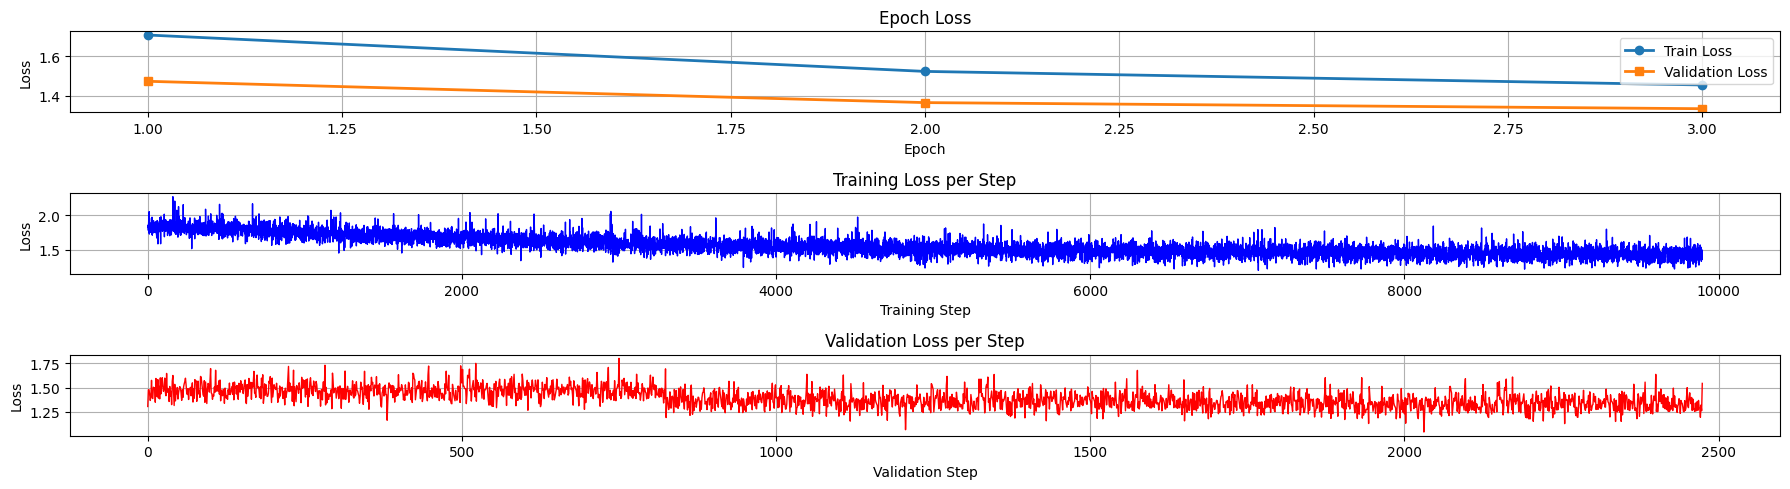

In [45]:
# TODO: Visualize the training and validation results

# Create three subplots:
#    a. Plot epoch-level training and validation losses
#    b. Plot step-level training losses
#    c. Plot step-level validation losses


import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# =====================================================
# 1. Epoch-level Loss
# =====================================================
plt.subplot(3, 1, 1)

plt.plot(
    range(1, epochs + 1),
    epoch_train_losses,
    marker="o",
    linewidth=2,
    label="Train Loss"
)

plt.plot(
    range(1, epochs + 1),
    epoch_val_losses,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Epoch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# =====================================================
# 2. Training Loss per Step
# =====================================================
plt.subplot(3, 1, 2)

plt.plot(
    all_train_step_nums,
    all_train_step_losses,
    linewidth=1,
    color="blue"
)

plt.title("Training Loss per Step")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)

# =====================================================
# 3. Validation Loss per Step
# =====================================================
plt.subplot(3, 1, 3)

plt.plot(
    all_val_step_nums,
    all_val_step_losses,
    linewidth=1,
    color="red"
)

plt.title("Validation Loss per Step")
plt.xlabel("Validation Step")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.savefig(
    Results_root + "training_loss_graphs.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
import os
import torch

SAVE_PATH = os.path.join(
    Results_root,
    "GPT-2-Finetuned"
)

os.makedirs(SAVE_PATH, exist_ok=True)

# Save BEST model weights
torch.save(
    model.state_dict(),
    os.path.join(SAVE_PATH, "best_model_weights.pt")
)

# Save tokenizer
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model weights and tokenizer saved at:\n{SAVE_PATH}")

✅ Model weights and tokenizer saved at:
E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/3 - HW3/Practical/Results/Q2_GPT2/GPT-2-Finetuned


# Inference (15 Points)

Complete the function below to generate comments (positive or negative) 

### loading the model and tokenizer (if needed)

In [23]:
import os
from transformers import GPT2LMHeadModel, GPT2Tokenizer

final_model_path = os.path.join(Results_root, "GPT-2-Finetuned")

best_tokenizer = GPT2Tokenizer.from_pretrained(final_model_path)
config = GPT2Config(
    vocab_size=len(best_tokenizer),
    n_positions=128,
    n_embd=192,
    n_layer=3,
    n_head=3,
    bos_token_id=best_tokenizer.bos_token_id,
    eos_token_id=best_tokenizer.eos_token_id
)


model = GPT2(config)

model.load_state_dict(
    torch.load(
        os.path.join(
            Results_root,
            "GPT-2-Finetuned",
            "model_weights.pt"
        ),
        map_location=device
    )
)

model.to(device)
model.eval()

GPT2(
  (transformer): ModuleDict(
    (wte): Embedding(50259, 192)
    (wpe): Embedding(128, 192)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-2): 3 x Block(
        (ln_1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=192, out_features=576, bias=True)
          (c_proj): Linear(in_features=192, out_features=192, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=192, out_features=768, bias=True)
          (c_proj): Linear(in_features=768, out_features=192, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=192, out_features=50259, bi

In [24]:
def generate_comment(model: nn.Module, tokenizer: Any, sentiment: str, max_length: int = 50) -> str:
    # TODO: Implement text generation with sentiment control
    # 1. Create the appropriate prefix based on the sentiment parameter
    # 2. Generate text using the model's generate method
    model.eval()

    # -----------------------------------------
    # Create sentiment prefix
    # -----------------------------------------
    if sentiment.lower() == "positive":
        prefix = "<POS>"

    elif sentiment.lower() == "negative":
        prefix = "<NEG>"

    else:
        raise ValueError(
            "Sentiment must be either 'positive' or 'negative'."
        )

    # -----------------------------------------
    # Tokenize prefix
    # -----------------------------------------
    device = next(model.parameters()).device

    input_ids = tokenizer(
        prefix,
        return_tensors="pt"
    )["input_ids"].to(device)

    # -----------------------------------------
    # Generate
    # -----------------------------------------
    with torch.no_grad():

        generated_ids = model.generate(
            input_ids=input_ids,
            max_length=max_length,
            temperature=0.8,
            top_k=50,
            top_p=0.9
        )

    # -----------------------------------------
    # Decode
    # -----------------------------------------
    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    ).strip()

    return generated_text

Generate 10 positive and 10 negative comments and evaluate your results

In [26]:
# TODO: Demonstrate the model's sentiment-controlled text generation

generated_rows = []
for i in range(10):
#    a. Generate a positive comment using the generate_comment function:
#    b. Generate a negative comment using the generate_comment function:
    positive_comment = generate_comment(
        model=model,
        tokenizer=tokenizer,
        sentiment="positive",
        max_length=128
    )
    generated_rows.append({
        "label": "Positive",
        "text": positive_comment
    })
    negative_comment = generate_comment(
        model=model,
        tokenizer=tokenizer,
        sentiment="negative",
        max_length=128
    )
    generated_rows.append({
        "label": "Negative",
        "text": negative_comment
    })


    print(f"Example {i+1}")
    print("-" * 60)
    print(f"Positive : {positive_comment}")
    print(f"Negative : {negative_comment}")
    print()


# Convert generated samples to DataFrame
df_generated = pd.DataFrame(generated_rows)

df_generated.head()

Example 1
------------------------------------------------------------
Positive : سیبزمینی عالی بود ولی بسیار خیلی خوب بود و حجم خوشمزه بود بود که در حتی که انتضاح تحویل نداشت همه شده بود که ک
Negative : خیلی خیلی بود و دو هم که هم چیز برنج پیتزا داشت بود و داشت که بسته بندی مونده بود که روغنداش برگر بودم رو از شده ش

Example 2
------------------------------------------------------------
Positive : برنج بار نامن تا دوتم گرم و نان از ساعت و کیفیت بود ولی کاملا بود پیتزا بهتری روی از درم برای دو شدن که رستوران شدهت
Negative : نون برگر مرغ سوخاری بود ولی خیلی بد بود از سرد بود و حجمز شده بود بسته بندی که تما بهتون سرد تا بیش خورد بود این هما

Example 3
------------------------------------------------------------
Positive : دوستم سرد دیر رسید با رسید هم که سرد بود اما رسید تحویل شده شده بود و کیفیت به دستم رسید برندید که بیکیفیت ب
Negative : کیفیت خیلی سرد و سالاد از شده بود سفارش دادم بدم بودم اینکه خوشمزه بود از که چرب سفارش دادم و گرم و گذاشتن خیل�

Example 4
---------------------------

,label,text
0,Positive,سیبزمینی عالی بود ولی بسیار خیلی خوب بود و حجم...
1,Negative,خیلی خیلی بود و دو هم که هم چیز برنج پیتزا داش...
2,Positive,برنج بار نامن تا دوتم گرم و نان از ساعت و کیفی...
3,Negative,نون برگر مرغ سوخاری بود ولی خیلی بد بود از سرد...
4,Positive,دوستم سرد دیر رسید با رسید هم که سرد بود اما ر...


In [34]:
df_generated.to_excel(Results_root+ "ten_generated_examples.xlsx", index=False)

## Inference Time Hyperparameters (10 Points)

Play with these parameters for the best results:
  
temperature, top_k, top_p

Briefly report what you saw and try to explain why is it happening. What is the effect of each one?

**Your Report**:  


The generation results were strongly affected by the values of `temperature`, `top_k`, and `top_p`.

- **Temperature:** Controls the randomness of the generation. Lower values make the model more deterministic and focused on the most probable tokens, while higher values increase randomness and creativity. Very high values can produce less coherent text.

- **Top-k:** Limits the sampling process to the `k` most probable tokens at each step. Smaller values make the output more predictable and focused, while larger values allow more possible tokens and therefore more variation.

- **Top-p:** Uses nucleus sampling and selects the smallest set of tokens whose cumulative probability reaches `p`. Lower values restrict the model to highly probable tokens, while higher values allow a wider range of possible tokens.

In general, lower values for these parameters produced more predictable and conservative outputs, while higher values produced more diverse but sometimes less coherent text. The best results were obtained by using moderate values, which provided a balance between diversity and grammatical coherence.

The quality of the generated text was also limited by the available hardware and the relatively small training budget. Therefore, the model was not trained for enough time or with enough computational resources to achieve the quality of a large pretrained language model. The generated outputs should therefore be considered as an experimental demonstration of text generation and sampling strategies rather than a production-quality language model.